# Titanic Dataset Analysis

## Objective
Analyze survival patterns using the Kaggle Titanic dataset.

## 1. Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

## 2. Load Dataset

In [2]:
df = pd.read_csv("train.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


**Insight:** The dataset contains passenger details and survival status.

## 3. Explore Dataset

In [3]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

**Insight:** Missing values exist in Age, Cabin, and Embarked.

## 4. Data Cleaning

In [4]:
df["Age"]=df["Age"].fillna(df["Age"].median())
df["Embarked"]=df["Embarked"].fillna(df["Embarked"].mode()[0])
df=df.drop(columns="Cabin")
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

### Data Cleaning Steps
- Filled missing Age values with the median.
- Filled missing Embarked values with the mode.
- Dropped Cabin because it contains too many missing values.


## 5. Survival by Gender

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64


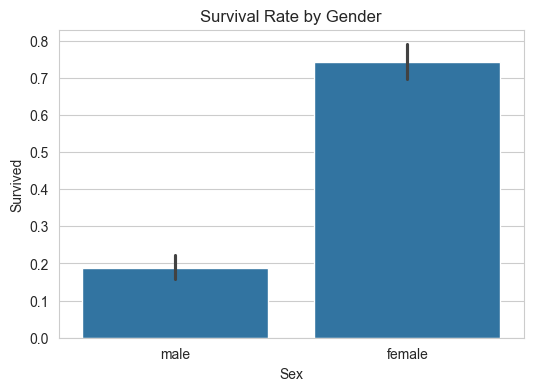

In [5]:
gender_survival=df.groupby("Sex")["Survived"].mean()
print(gender_survival)

plt.figure(figsize=(6,4))
sns.barplot(data=df,x="Sex",y="Survived")
plt.title("Survival Rate by Gender")
plt.show()

**Insight:** Female passengers had a much higher survival rate than male passengers.

## 6. Survival by Passenger Class

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64


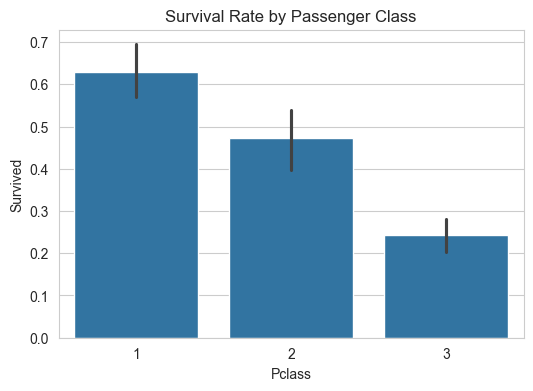

In [6]:
class_survival=df.groupby("Pclass")["Survived"].mean()
print(class_survival)

plt.figure(figsize=(6,4))
sns.barplot(data=df,x="Pclass",y="Survived")
plt.title("Survival Rate by Passenger Class")
plt.show()

**Insight:** First-class passengers had the highest survival rate, while third-class passengers had the lowest.

## 7. Survival by Age Group

C:\Users\gajen\AppData\Local\Temp\ipykernel_19388\1457861611.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_survival=df.groupby("AgeGroup")["Survived"].mean()


AgeGroup
Child          0.579710
Teen           0.428571
Young Adult    0.353271
Adult          0.400000
Senior         0.227273
Name: Survived, dtype: float64


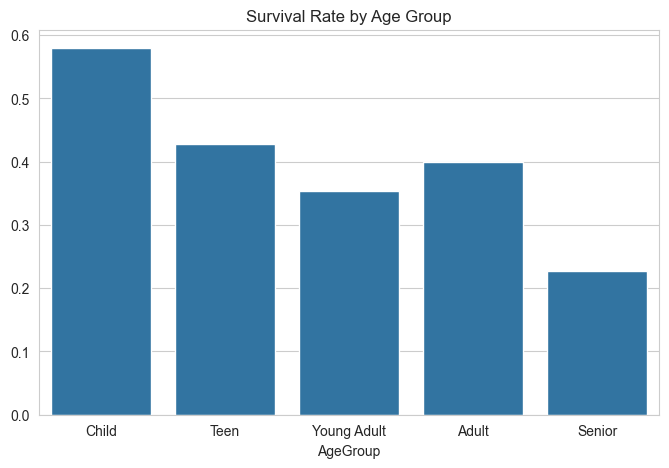

In [7]:
bins=[0,12,18,35,60,100]
labels=["Child","Teen","Young Adult","Adult","Senior"]
df["AgeGroup"]=pd.cut(df["Age"],bins=bins,labels=labels)

age_survival=df.groupby("AgeGroup")["Survived"].mean()
print(age_survival)

plt.figure(figsize=(8,5))
sns.barplot(x=age_survival.index,y=age_survival.values)
plt.title("Survival Rate by Age Group")
plt.show()

**Insight:** Children and young adults generally had better survival rates.

## 8. Histogram of Passenger Ages

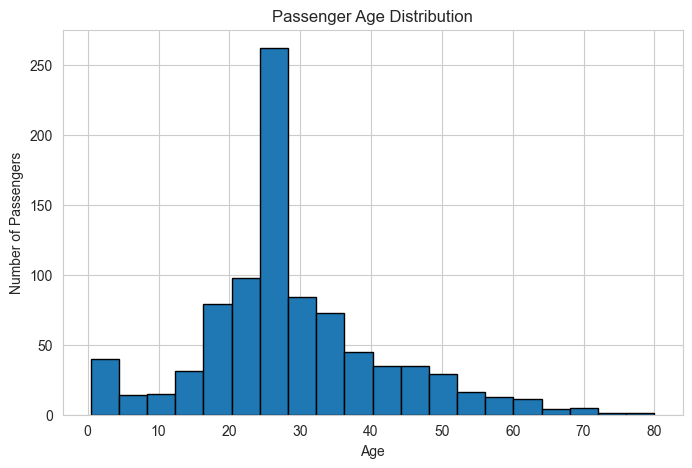

In [8]:
plt.figure(figsize=(8,5))
plt.hist(df["Age"],bins=20,edgecolor="black")
plt.title("Passenger Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")
plt.show()

**Insight:** Most passengers were between 20 and 40 years old.

## 9. Final Answers

- **Who survived more?** Females.
- **Did passenger class affect survival?** Yes, first class had the highest survival rate.
- **Survival by age group?** Children and younger passengers generally survived more often.


## 10. Conclusion
- Female passengers had higher survival chances.
- Passenger class strongly affected survival.
- Most passengers were 20–40 years old.
- Cleaning missing values improved analysis quality.